# Relatório Final do Trabalho (RFT)

## Integrantes do Grupo 6:

- 11201811864 - Lucas Araujo Avelino Dos Santos
- 11201920812 - Vithório da Cunha Marques
- 11202231732 - Wagner Ryu Kamiya

### Data da última atualização: 27/04/2026

# **Título: Processamento Digital de Imagens aplicado à customização de carrinhos de brinquedo**

# Introdução

## Contexto e Cenário de Aplicação

Em empresas que produzem ou comercializam brinquedos, principalmente carrinhos em miniatura, é comum a necessidade de registrar imagens dos produtos para catálogos digitais, divulgação em lojas online ou organização de estoque. Muitas vezes essas imagens precisam passar por edição manual para remover o fundo, ajustar iluminação ou destacar partes do produto.

Esse processo pode ser demorado quando há muitos itens para registrar. Além disso, identificar visualmente diferentes partes do produto pode ajudar tanto na apresentação do item quanto em análises rápidas de suas características.

Diante disso, surge a proposta de um sistema capaz de capturar imagens de carrinhos de brinquedo usando uma webcam e realizar automaticamente a separação do objeto do plano de fundo, segmentar partes do carrinho (rodas e restante do carrinho) e alterar a cor do brinquedo através do input do usuário.

## Objetivos

O objetivo do sistema é capturar imagens de carrinhos de brinquedo e realizar o processamento dessas imagens para separar o carrinho do fundo. Após essa etapa, o sistema busca segmentar as rodas do restante do carrinho. Com esses segmentos identificados, o software, possibilita a coloração do carrinho de acordo com input do usuário.

## Como o sistema é utilizado

O usuário posiciona o carrinho de brinquedo em frente a uma webcam conectada ao computador. O sistema captura a imagem e realiza automaticamente a segmentação, separando o carrinho do plano de fundo.

Depois disso, o usuário pode interagir com a interface do sistema para alterar a cor do brinquedo.

As alterações são exibidas na própria imagem da webcam e salvas em imagens no computador.

## Benefícios para o usuário

O sistema facilita o processo de captura e preparação de imagens de produtos, reduzindo a necessidade de edição manual. A separação automática do fundo e a alteração da cor do objeto ajudam a gerar imagens mais organizadas para uso em catálogos ou apresentações.

Além disso, a aplicação rápida de modificações visuais permite criar diferentes versões da imagem do produto de forma simples e rápida.

## Fundamentação teórica

A pipeline segue uma lógica de **segmentação + refinamento + edição** , aplicada aqui ao problema de extrair um carrinho de brinquedo da imagem e alterar sua cor de forma controlada.

A primeira etapa é a aplicação de um filtro Gaussiano (GaussianBlur(5, 1.2)),cuja função é reduzir ruídos e pequenas variações de intensidade que poderiam comprometer etapas posteriores baseadas em gradiente e limiarização. Ao suavizar a imagem, cria-se uma representação mais estável das estruturas principais, no caso, o contorno do carrinho.

Na sequência, o operador Sobel (Sobel(3, 2.0)) é utilizado para estimar o gradiente da imagem nas direções horizontal e vertical. Teoricamente, ele aproxima derivadas de primeira ordem, destacando regiões com variação abrupta de intensidade, o que, para o nosso problema, se aplica às bordas. Como o carrinho é definido por suas descontinuidades em relação ao fundo, essa etapa enfatiza suas fronteiras, preparando a imagem para uma segmentação mais eficiente.

Em seguida, aplica-se a limiarização automática de Otsu (ThresholdOtsu()), que escolhe um limiar ótimo com base na maximização da variância entre classes no histograma. O resultado é uma imagem binária (preto e branco) onde, o carrinho aparece separado do fundo. Essa etapa soluciona o problema de distinguir regiões de interesse (o carrinho e o plano de fundo), embora ainda sujeita a imperfeições devido a iluminação da imagem.

O próximo passo é a execução de um bloco paralelo com Parallel([UsePrevious(0), WatershedMask(...)]). Aqui aplica-se uma segmentação mais complexa com Watershed. O método Watershed modela a imagem como uma superfície topográfica, onde intensidades representam altitudes. A partir de marcadores (estimados via operações morfológicas e transformada de distância), o algoritmo “inunda” regiões até encontrar fronteiras, separando objetos adjacentes. No contexto do carrinho, isso permite isolar sua região mesmo quando há contato com outros elementos ou fundo complexo. O uso de operações como opening e dilatação na construção dos marcadores garante melhor definição de fundo e objeto, enquanto o parâmetro distanceThreshold controla a identificação das regiões centrais do objeto.

Após obter a máscara segmentada, a imagem original é convertida para o espaço de cor HLS (CvtColor(cv2.COLOR_RGB2HLS)). A fundamentação dessa escolha está na separação entre luminância (L) e componente cromática (H e S). Isso permite alterar a cor (matiz, Hue) sem impactar diretamente brilho e contraste percebidos, o que é importante para manter a aparência natural do carrinho e evitar que a imagem pareça mal editada.

Antes de aplicar a máscara, realiza-se uma erosão morfológica (Erode(9, KernelType.ELLIPSE)), removendo ruídos e afinando regiões.

A etapa seguinte, implementada via AggregatorYIntoX com ApplyHueWithMask, realiza a fusão entre imagem e máscara. Trata-se de uma operação de processamento onde apenas os pixels pertencentes à região segmentada têm seu valor de matiz (Hue) alterado. Isso garante que a modificação de cor seja localizada exclusivamente no carrinho, preservando o restante da imagem.

Por fim, a imagem é reconvertida ao espaço RGB (CvtColor(cv2.COLOR_HLS2RGB)), retornando a um formato padrão de exibição. Como a alteração foi feita apenas no canal de matiz, o resultado mantém coerência visual em termos de iluminação e sombreamento, mas com a cor do carrinho modificada.

Em síntese, a pipeline realiza as seguintes operações: (1) suavização para robustez, (2) detecção de bordas para evidenciar estruturas, (3) binarização para separação inicial, (4) segmentação Watershed para isolamento preciso, e (5) manipulação de cor em espaço adequado com base em máscara. Essa sequência reflete um fluxo baseado em: pré-processamento → segmentação → refinamento → edição localizada.

# Materiais e métodos

## Diagrama de Blocos Funcional do SPV

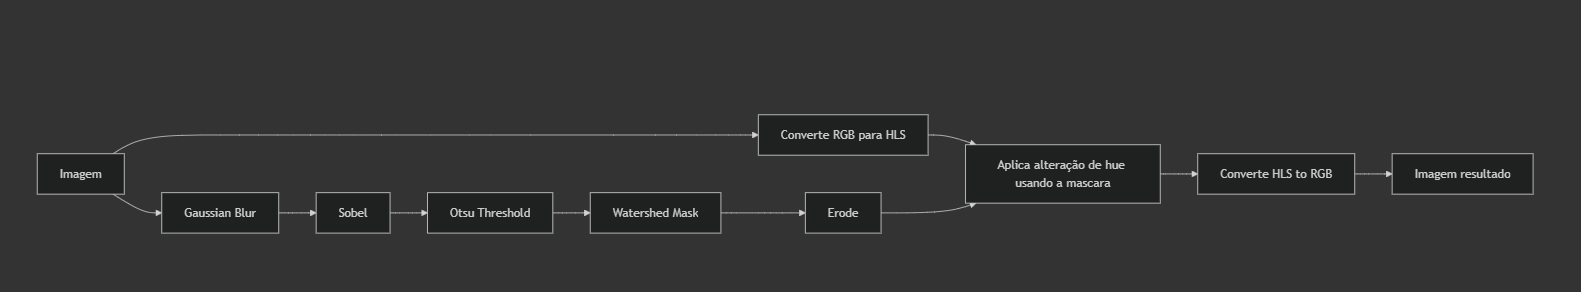

## Descrição da implementação do Sistema de Processamento da Visual (SPV)

A ideia inicial foi construir a pipeline como uma sequência iterável de operações, cada etapa é uma função que recebe a imagem atual e a lista de imagens geradas até então. Isso ajudou a gente alterar facilmente a ordem das operações e ajustar parâmetros sem ter que ficar mudando código de lugar para testar.

Dessa forma criamos duas libs principais, a primeira com o objetivo de fazer o rendering das imagens, ou da pipeline no caso do video, e outra com as funçoes core do programa, as funções que alteram as imagens são funções que retornam outras funções.

```
def GaussianBlur(size, sigma):
  def result(img, _):
    return cv2.GaussianBlur(img, (size, size), sigma)
  return result
```
GaussianBlur recebe os parametros size e sigma, o valor que ela retorna é uma função que rece uma imagem e uma lista de imagems, e aplica o gaussian blur na imagem.

```
def Sobel(size, scale):
  def result(img, _):
    grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=size, scale=scale)
    grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=size, scale=scale)
    return cv2.convertScaleAbs(grad_x) + cv2.convertScaleAbs(grad_y)
  return result
```
Sobel recebe os parametros size (tamanho do kernel) e scale (fator de escala); o que ela retorna é uma função que aplica os operadores de Sobel nas direções x e y, converte para absoluto e soma, produzindo uma imagem que destaca as bordas (gradiente).

```
def ThresholdOtsu():
  def result(img, _):
    if img.ndim == 3:
      img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh
  return result
```
ThresholdOtsu não recebe parametros; retorna uma função que converte a imagem para grayscale se necessário e aplica a limiarização automática de Otsu, retornando uma máscara binária onde objeto e fundo são separados.

```
def Parallel(funcs: list):
  def result(img, prevs):
    results = []
    for func in funcs:
      results.append(func(img, prevs))
    return results
  return result
```
Parallel recebe uma lista de funções e retorna uma função que aplica cada uma delas à mesma imagem/estado, retornando uma lista com os resultados, nós usamos essa função quando queriamos testar varias coisas ao mesmo tempo e tambem.

```
def UsePrevious(index):
  def result(img, previousResults):
    return previousResults[index]
  return result
```
UsePrevious recebe um índice e retorna uma função que simplesmente retorna o resultado anterior naquele índice; útil para reutilizar saídas de passos anteriores.

```
def WatershedMask(openingSize=3, sureBgIterations=2, distanceThreshold=0.4, kernelType=KernelType.ELLIPSE, amountOfAreas=1, sourceIndex=None, closeSize=None, excludeBorderLabels=True, maxAreaRatio=0.35):
  def result(img, previousResults):
    # seleciona fonte se sourceIndex for fornecido, calcula marcadores via distância e operações morfológicas, roda cv2.watershed, filtra rótulos e retorna máscara preenchida
    pass  # descrição resumida na documentação
  return result
```
WatershedMask recebe parametros para controlar pré-processamento (abertura, dilatação de fundo, threshold de distância, tipo de kernel, número de áreas, etc.); retorna uma função que gera marcadores, executa o algoritmo Watershed, seleciona os rótulos mais relevantes (filtrando por bordas e tamanho) e devolve uma máscara binária preenchida representando a região segmentada. Em caso de falha, retorna uma máscara fallback baseada em operações morfológicas e contornos.

```
def CvtColor(code):
  def result(img, _):
    return cv2.cvtColor(img, code)
  return result
```
CvtColor recebe um código de conversão (por exemplo cv2.COLOR_RGB2HLS ou cv2.COLOR_HLS2RGB); retorna uma função que aplica a conversão de espaço de cor na imagem.

```
def Erode(size, kernelType = KernelType.RECT):
  def result(img, _):
    if kernelType == KernelType.RECT:
      kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (size, size))
    elif kernelType == KernelType.ELLIPSE:
      kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))
    elif kernelType == KernelType.CROSS:
      kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (size, size))
    return cv2.erode(img, kernel, iterations=1)
  return result
```
Erode recebe tamanho e tipo de kernel; retorna uma função que aplica erosão morfológica para remover ruídos finos e afinar regiões na máscara/imagem.

```
def ParallelAggregable(funcs: list):
  def withMask(mask):
    def result(img, prevs):
      results = []
      for func in funcs:
        results.append(func(mask)(img, prevs))
      return results
    return result
  return withMask
```
ParallelAggregable recebe uma lista de geradores de função (cada um esperando uma máscara) e retorna um gerador `withMask(mask)` que por sua vez retorna uma função aplicável `(img, prevs)`; isso permite aplicar múltiplas operações configuradas pela mesma máscara em paralelo.

```
def ApplyHueWithMask(new_hue):
  def withMask(mask):
    def result(img, _):
      h, s, v = cv2.split(img)
      h[mask == 255] = new_hue
      return cv2.merge([h, s, v])
    return result
  return withMask
```
ApplyHueWithMask recebe o valor de matiz `new_hue` e retorna um gerador `withMask(mask)` que produz uma função `(img, _)` assumindo imagem em HLS; essa função altera o canal H apenas nos pixels onde a máscara vale 255, aplicando a cor apenas na região segmentada.

Estas descrições seguem o mesmo formato do exemplo do `GaussianBlur` e cobrem as funções utilizadas na pipeline principal do laboratório SPVLex.


## Lista dos arquivos: dos código-fonte, imagens, vídeos, e arquivos auxiliares

- README.MD: arquivo que contém as instruções de como preparar o ambiente e executar o projeto.
- pipeline.ipynb: código principal em que aplica os conceitos aprendidos em aula sobre a imagem e sobre o vídeo capturado na webcam.
- image_transformers.py: biblioteca autoral que contém todas funções das transformações aprendidas em aula.
- render_pipeline.py: biblioteca autoral que contém as funções de exibição das imagens e execução da captura via webcam.
- spv_lex.ipynb: jupyter notebook com o conteúdo do laboratório experimental criado para a entrega da etapa 5 da atividade.
- images: diretório que contém duas imagens e dois vídeos base utilizados durante os testes do SPV.
- baks: diretório que contém os vídeos de output das transformações utilizadas com os vídeos do diretório images.

- Output da pipeline de transformação da imagem do carrinho passo a passo:
  
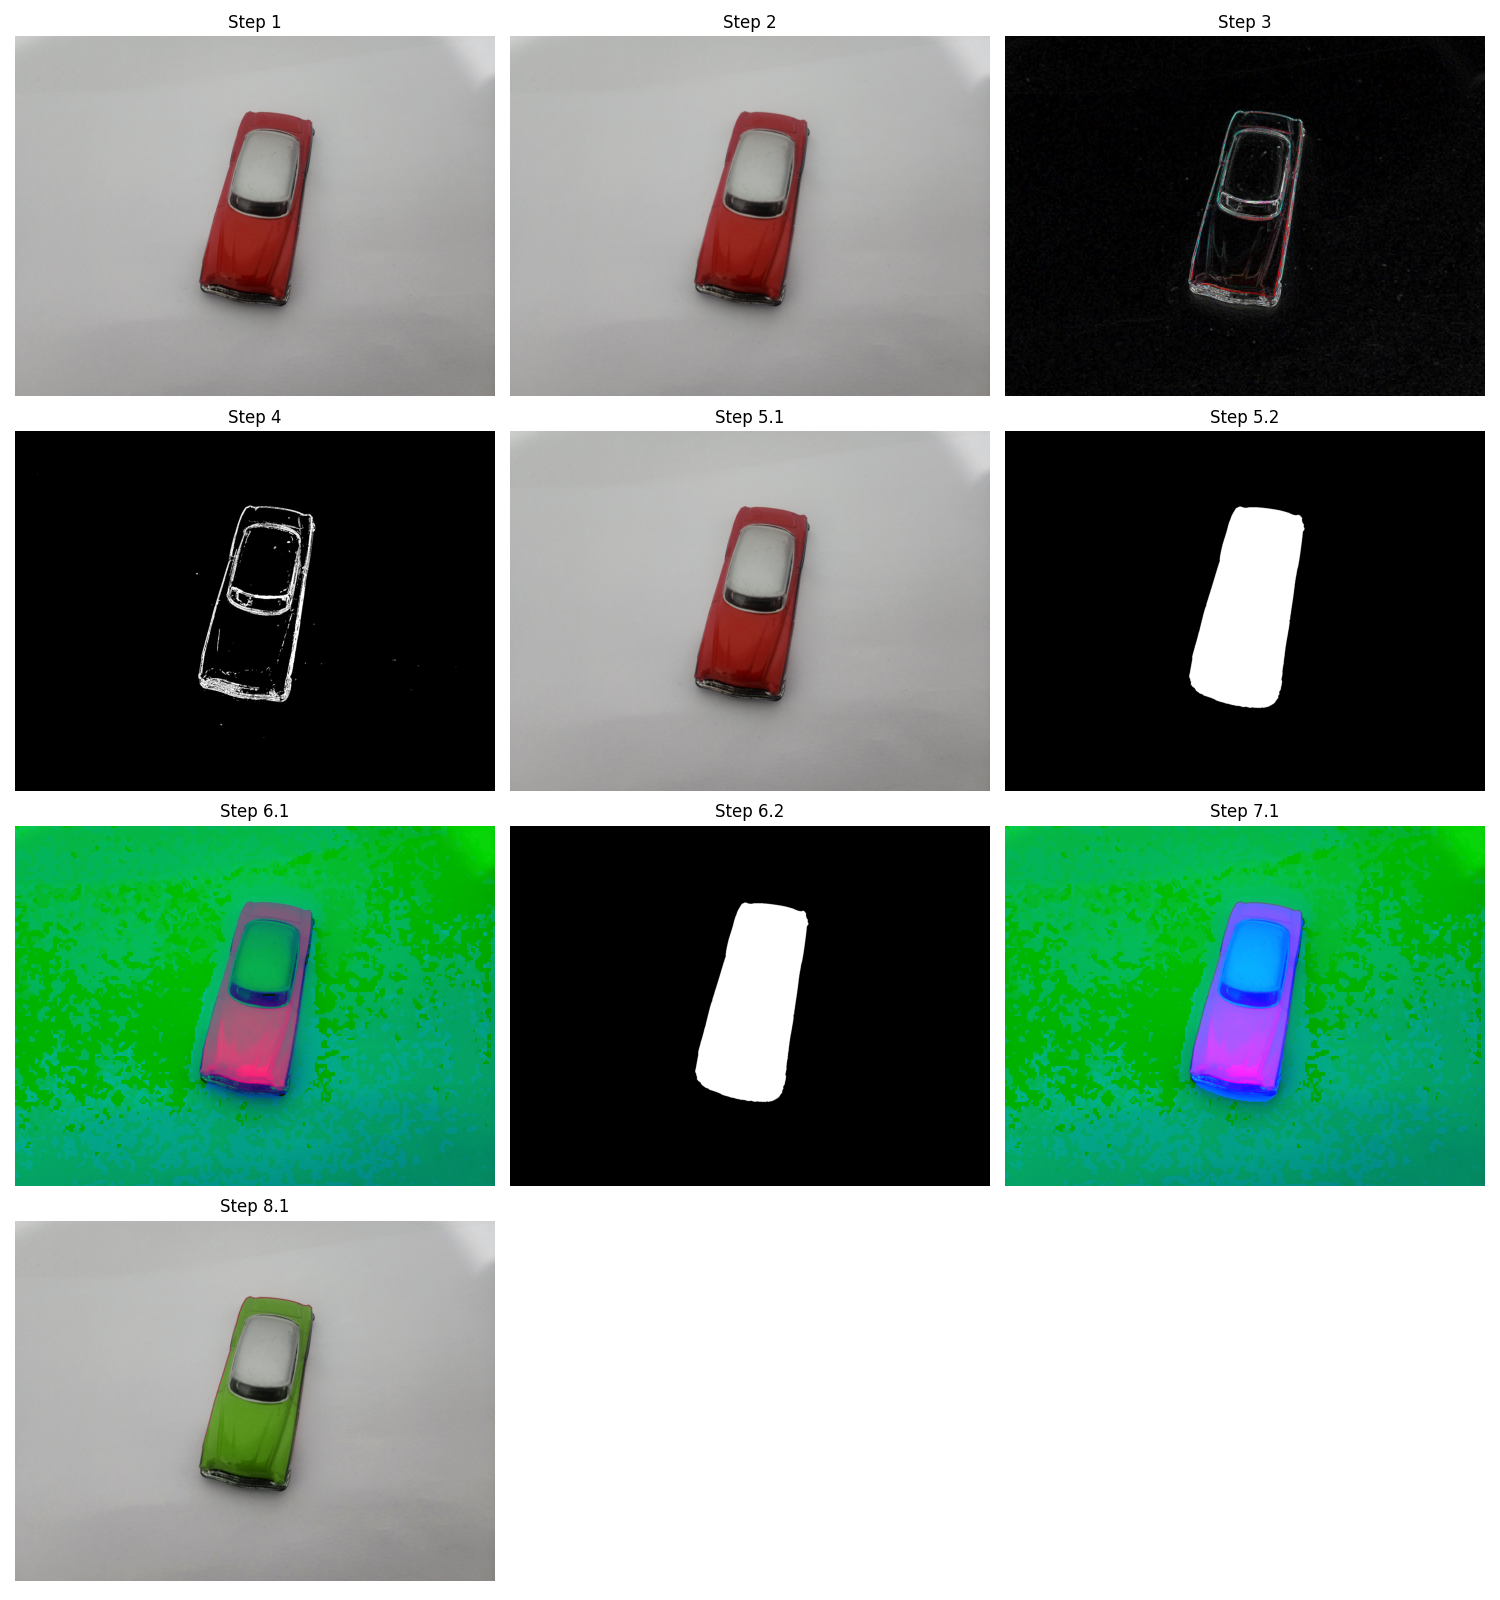

## Análise técnica

Com a realização do projeto, observa-se que ele atendeu parcialmente aos objetivos.
Foi possível criar um sistema que identifica o objeto, o separa do fundo da imagem e altera sua cor, contudo também observamos que há um contorno da cor original do objeto na imagem final, o que deve ser corrigido em versões futuras para cobrir a sua totalidade.
Além disso, objetos em movimento apresentaram imprecisões na troca de cor, com dificuldade para identificar suas fronteiras e atualizar a cor do objeto identificado em tempo real hábil.
Apesar destes pontos de melhoria, o projeto foi capaz de alterar a cor eficientemente dos objetos de teste e se apresentou uma ótima ferramenta para agilizar processos de edição e criação de protótipos de novos objetos em cores diferentes.


# Laboratório experimental

## Roteiro do laboratório experimental

Neste roteiro você irá executar as transformações utilizadas para o desenvolvimento do SPV através da webcam e interação com a interface gráfica.
Explore as transformações disponíveis, observe e descreva os resultados.

Ao executar o código, serão exibidas duas janelas:
1. Janela com todas as transformações executadas.
2. Janela com os sliders para as transformações. Os valores dos sliders são exibidos na imagem acima. Aumente o tamanho da janela para melhorar a visibilidade conforme necessário.

Altere os valores dos sliders e observe as mudanças nas imagens.

### Resumo simplificado das transformações utilizadas na pipeline

| Etapa           | Função                                             |
|-----------------|----------------------------------------------------|
| Blur            | Remove ruído                                       |
| Sobel           | Detecta bordas                                     |
| Otsu            | Binariza                                           |
| WatershedMask   | Segmenta o objeto principal e gera máscara preenchida |
| Erode           | Limpa máscara de aplicação de cor                  |
| HLS             | Trabalha com cor                                   |
| ApplyHueWithMask| Aplica cores nas regiões                           |
| RGB             | Volta ao formato final                             |

### Resumo simplificado do efeito dos sliders

| Slider         | O que muda na imagem        |
| -------------- | --------------------------- |
| gaussian_size  | suavidade geral             |
| gaussian_sigma | intensidade do blur         |
| sobel_size     | espessura das bordas        |
| sobel_scale    | força das bordas            |
| morph_size     | limpeza / remoção de ruído  |
| masks          | tamanho/alcance das regiões |
| hue            | cor aplicada                |
| mode           | comportamento global        |


Imagem obtida durante a aula prática do SPV Lex sendo utilizado por um estudante de outro grupo:

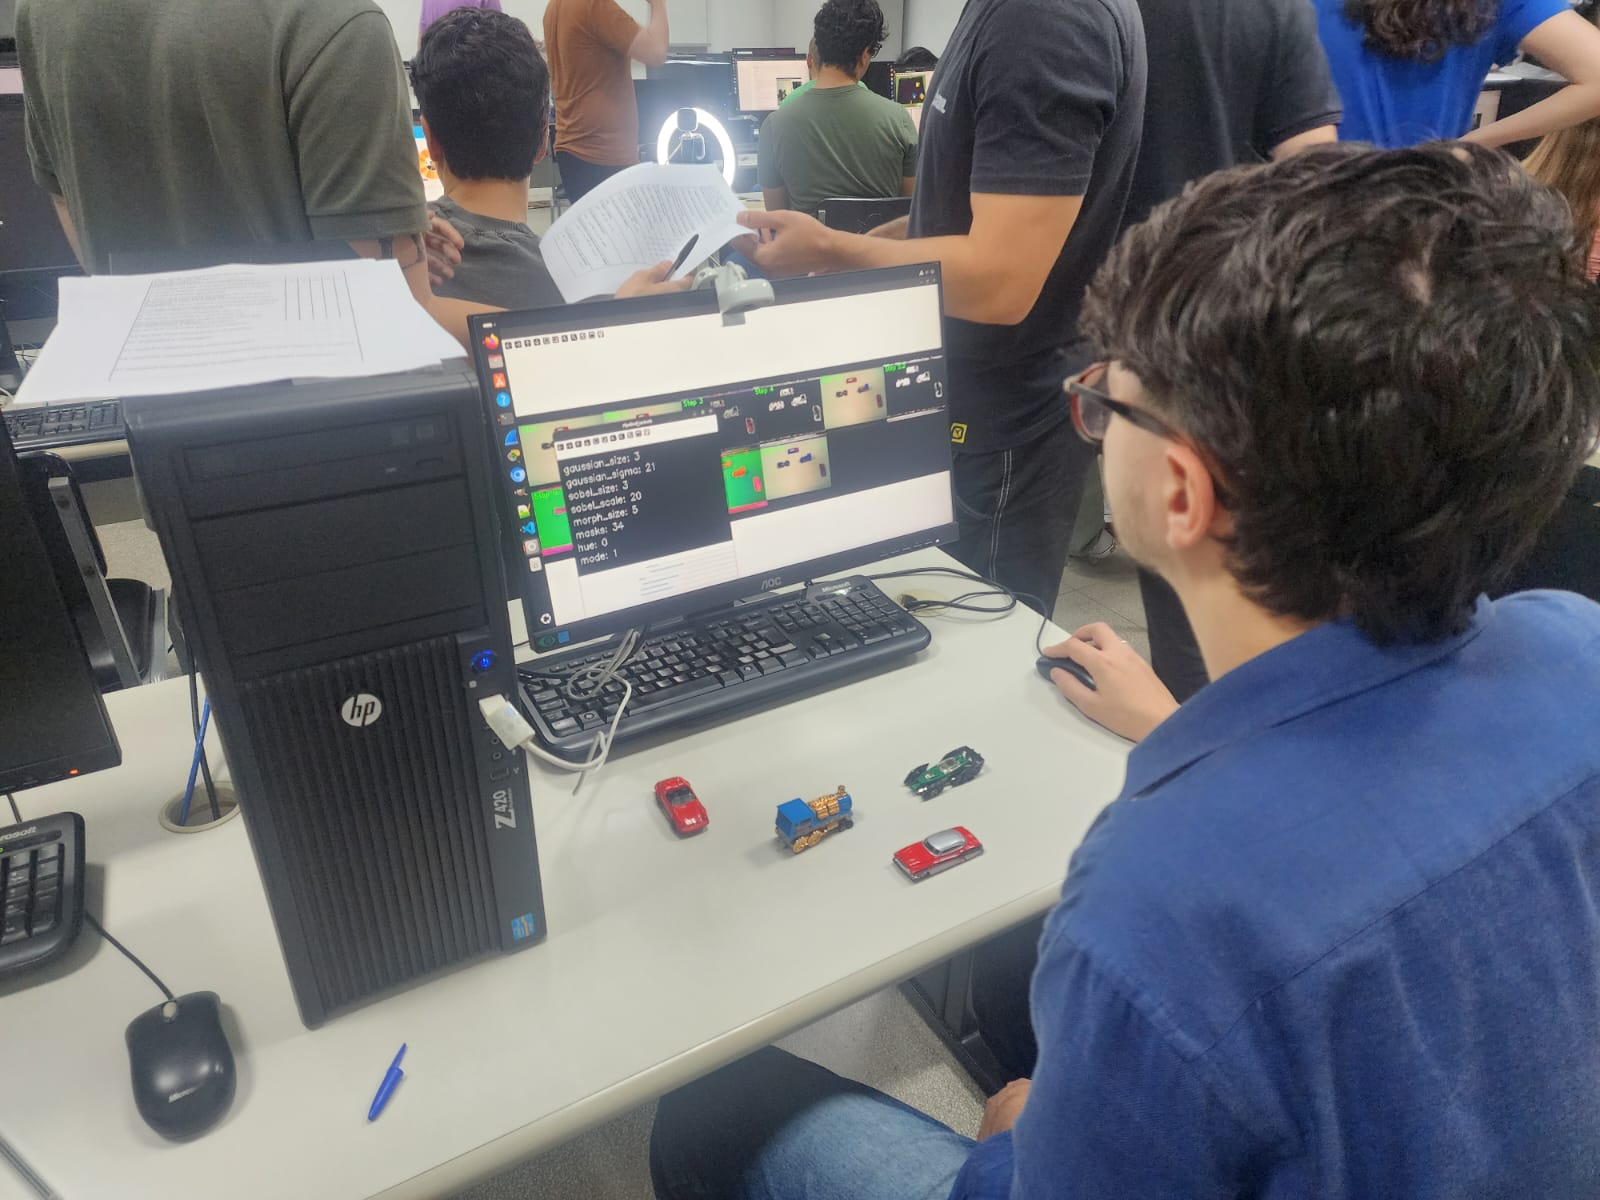

## Análise dos resultados experimentais

De acordo com os feedbacks obtidos dos alunos que testaram o sistema, foi possível atingir os objetivos e houve uma maioria de opiniões positivas. A possibilidade de alterar as cores em tempo real de acordo com o desejo do usuário e a precisão na seleção apenas do carrinhos se mostraram o pontos fortes da implementação.

Entre as sugestões de melhoria, encontram-se alterações na usabilidade do usuário com foco no uso dos sliders para manipular os parâmetros e na exibição das imagens em diferentes janelas.

No geral, os usuários não tiveram dificuldades no uso da ferramenta e aprovaram sua eficácia.

Os formulários podem ser obtidos no arquivo teste_de_campo.pdf

# Conclusão

O projeto cumpriu o objetivo final de separar e alterar a cor de carrinhos de brinquedo ao passo que aplica conceitos aprendidos durante a aula de Processamento Digital de Imagens. Foram explorados diversos parâmetros das funções e o resultado final foi obtido através de análises visuais subjetivas. Apesar disso, ainda há espaço para melhorias, como o problema de uma fronteira fina da cor original do objeto e a dificuldade de transformação de objetos em movimento.

Para estudos futuros, o projeto pode almejar resolver os pontos de melhoria citados e aumentar o escopo de carrinhos de brinquedo para outros objetos, como roupas, capacetes, relógios etc.

# Referências bibliográficas

- GONZALEZ, R. C.; WOODS, R. E. Digital image processing.
3a edição. New Jersey, USA: Pearson/Prentice Hall, 2008.
<https://www.imageprocessingplace.com/>

- Richard Szeliski. Computer Vision: Algorithms and
Applications, 2nd ed. Springer, 2022.
<https://szeliski.org/Book/> © 2022 , The University of
Washington

# Anexos

- README.MD: arquivo que contém as instruções de como preparar o ambiente e executar o projeto.
- pipeline.ipynb: código principal em que aplica os conceitos aprendidos em aula sobre a imagem e sobre o vídeo capturado na webcam.
- image_transformers.py: biblioteca autoral que contém todas funções das transformações aprendidas em aula.
- render_pipeline.py: biblioteca autoral que contém as funções de exibição das imagens e execução da captura via webcam.
- spv_lex.ipynb: jupyter notebook com o conteúdo do laboratório experimental criado para a entrega da etapa 5 da atividade.